In [ ]:
### Task A1: Problem Understandin
# 1. Input Features and Output Label
               Input Features:
RGB images of plant leaves resized to 128 × 128 × 3 pixels.
Each pixel value represents color intensity.

Output Label:
One of three leaf disease classes, represented using one-hot encoding:

Class 0

Class 1

Class 2


# 2. Why ANN Is Suitable

ANN can learn non-linear relationships between input features and output labels.
After flattening images, ANN treats pixel values as numerical features.
Suitable as a baseline model to understand learning behavior before CNNs.
Easy to implement and computationally less complex.

Note: ANN does not preserve spatial features, but it is acceptable for academic baseline analysis.

# 3. Comment on Class Imbalance

If one class has significantly more samples than others:
Model may become biased toward majority class
Accuracy may appear high but performance will be poor on minority classes
This can be identified using:
training_set.class_names

Class imbalance can be handled using:
Data augmentation
Class weights (optional)###

In [2]:
## Task 2
import tensorflow as tf
import matplotlib.pyplot as plt



In [3]:
import os

print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\Shahina Bhanu\OneDrive\Desktop\leaf_disease_detection


In [4]:
current_directory = os.getcwd()

train_path = os.path.join(current_directory, "dataset", "Training")
valid_path = os.path.join(current_directory, "dataset", "Validation")
test_path  = os.path.join(current_directory, "dataset", "Testing")



In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)


Found 3251 files belonging to 3 classes.


In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)


Found 416 files belonging to 3 classes.


In [7]:
ann = tf.keras.models.Sequential()


In [8]:
##TASK 2: Implement Fully Connected ANN
ann.add(tf.keras.layers.Flatten(input_shape=(128, 128, 3)))

ann.add(tf.keras.layers.Dense(1024, activation='relu'))
ann.add(tf.keras.layers.Dropout(0.4))

ann.add(tf.keras.layers.Dense(512, activation='relu'))
ann.add(tf.keras.layers.Dropout(0.3))

ann.add(tf.keras.layers.Dense(256, activation='relu'))

# Output layer (3 classes)
ann.add(tf.keras.layers.Dense(3, activation='softmax'))



c:\Users\Shahina Bhanu\OneDrive\Desktop\leaf_disease_detection\leafvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [11]:
ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,989,571 (194.51 MB)

 Trainable params: 50,989,571 (194.51 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
 ## TASK 2 :Train the Model

training_history = ann.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)



Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 31s 282ms/step - accuracy: 0.3559 - loss: 321.0152 - val_accuracy: 0.3918 - val_loss: 85.9207
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 252ms/step - accuracy: 0.3823 - loss: 15.6294 - val_accuracy: 0.3966 - val_loss: 1.0925
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 249ms/step - accuracy: 0.4023 - loss: 1.2055 - val_accuracy: 0.4014 - val_loss: 1.0869
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.4042 - loss: 1.3583 - val_accuracy: 0.3966 - val_loss: 1.0847
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.4051 - loss: 1.5688 - val_accuracy: 0.3990 - val_loss: 1.0811
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 26s 249ms/step - accuracy: 0.4014 - loss: 1.0859 - val_accuracy: 0.3918 - val_loss: 1.0831
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.4008 - loss: 1.0827 - val_accuracy: 0.3918 - val_loss: 1.0823
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.4008 - los

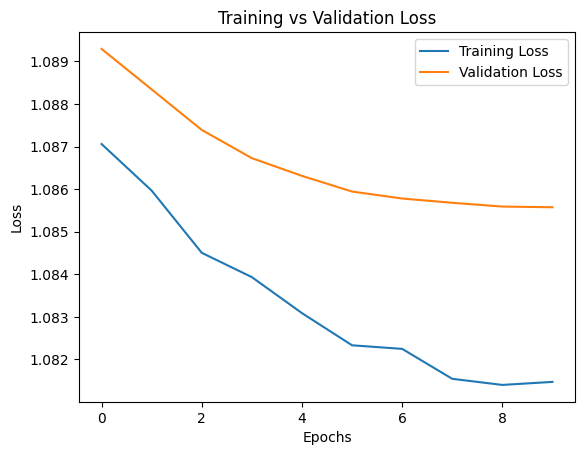

In [ ]:
 ## TASK 2 : Plot for the training and validation loss
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


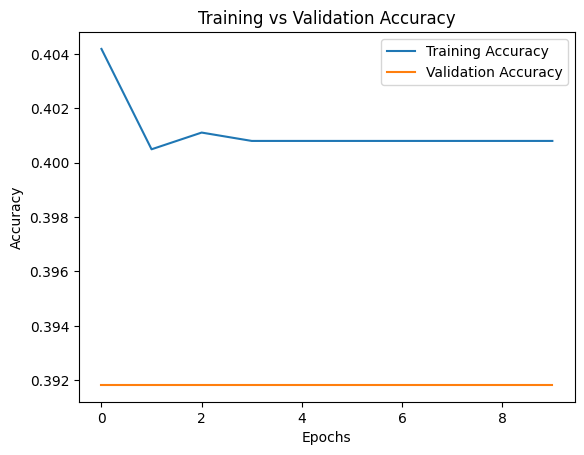

In [30]:
## Plot for the accuracy
plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [15]:
### TASK 4:Reduced Model Complexity

ann_simple = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(128, 128, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


In [16]:
## TASK 4: Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [32]:
early_model = tf.keras.models.Sequential()

early_model.add(tf.keras.layers.Flatten(input_shape=(128, 128, 3)))
early_model.add(tf.keras.layers.Dense(512, activation='relu'))
early_model.add(tf.keras.layers.Dense(256, activation='relu'))
early_model.add(tf.keras.layers.Dense(3, activation='softmax'))

early_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [37]:
history_early = early_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.5414 - loss: 10.1495 - val_accuracy: 0.4567 - val_loss: 12.7634
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.5441 - loss: 6.8949 - val_accuracy: 0.4087 - val_loss: 4.5004
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.5463 - loss: 4.0986 - val_accuracy: 0.5096 - val_loss: 2.3984
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.4094 - loss: 12.0581 - val_accuracy: 0.4087 - val_loss: 22.4873
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.3953 - loss: 27.7757 - val_accuracy: 0.2284 - val_loss: 67.4524
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.3617 - loss: 8.3147 - val_accuracy: 0.3918 - val_loss: 1.0824
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.4008 - loss: 1.0815 - val_accuracy: 0.3918 - val_loss: 1.0806
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - accuracy: 0.4008 - l

In [ ]:
  ## TASK 4: Dropout
dropout_model = tf.keras.models.Sequential()

dropout_model.add(tf.keras.layers.Flatten(input_shape=(128, 128, 3)))
dropout_model.add(tf.keras.layers.Dense(512, activation='relu'))
dropout_model.add(tf.keras.layers.Dropout(0.5))
dropout_model.add(tf.keras.layers.Dense(256, activation='relu'))
dropout_model.add(tf.keras.layers.Dropout(0.3))
dropout_model.add(tf.keras.layers.Dense(3, activation='softmax'))


In [35]:
dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [36]:
history_dropout = dropout_model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20
)


Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.3648 - loss: 1482.9143 - val_accuracy: 0.3894 - val_loss: 1.1030
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.3940 - loss: 1.2568 - val_accuracy: 0.3894 - val_loss: 1.0823
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - accuracy: 0.4008 - loss: 1.0813 - val_accuracy: 0.3894 - val_loss: 1.0816
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.4008 - loss: 1.0810 - val_accuracy: 0.3894 - val_loss: 1.0816
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.4005 - loss: 1.0836 - val_accuracy: 0.3894 - val_loss: 1.0818
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.4008 - loss: 1.0813 - val_accuracy: 0.3894 - val_loss: 1.0818
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.4008 - loss: 1.0837 - val_accuracy: 0.3894 - val_loss: 1.0818
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.4008 - loss

In [1]:
ann_overfit = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(128, 128, 3)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

ann_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


NameError: name 'tf' is not defined